In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import style

pd.set_option('display.max_rows', 1000)
from datetime import date
import warnings
warnings.filterwarnings('ignore')


In [2]:
df = pd.read_csv('/home/abhishek/Documents/INDIAN summer/Indian Summers - Over the years.csv')


In [3]:
df.shape

(13650, 20)

In [4]:
df.describe()

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,windspeed,winddir,sealevelpressure,cloudcover,visibility,moonphase
count,13615.000000,13615.000000,13605.000000,13614.000000,13614.000000,13604.000000,13605.000000,13605.000000,13605.000000,13600.000000,10631.000000,13605.000000,13605.000000,13650.000000
mean,36.728248,25.821160,31.151510,40.212605,27.221324,33.704535,19.049607,54.638537,20.078552,205.236559,1004.302446,37.120235,4.666645,0.500692
std,4.115452,3.212167,3.074874,5.389016,4.907125,4.666616,5.966341,19.521510,9.886468,64.181345,4.183785,24.684504,1.382413,0.308204
min,0.000000,0.000000,19.900000,0.000000,0.000000,19.900000,-10.300000,7.410000,0.000000,0.000000,908.500000,0.000000,1.300000,0.000000
25%,34.000000,23.700000,29.200000,36.500000,23.700000,30.200000,15.000000,38.190000,14.800000,159.800000,1001.600000,16.700000,3.700000,0.250000
50%,37.000000,26.000000,31.100000,40.000000,26.000000,33.500000,20.300000,56.120000,19.500000,218.300000,1004.700000,36.700000,4.300000,0.500000
75%,39.800000,28.100000,33.200000,43.700000,31.100000,37.200000,24.000000,71.410000,24.100000,258.625000,1007.300000,54.000000,5.600000,0.760000
max,50.000000,37.000000,40.500000,79.200000,43.300000,48.500000,29.100000,99.040000,263.200000,360.000000,1026.200000,100.000000,12.300000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13650 entries, 0 to 13649
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   City              13650 non-null  object 
 1   Date              13650 non-null  object 
 2   tempmax           13615 non-null  float64
 3   tempmin           13615 non-null  float64
 4   temp              13605 non-null  float64
 5   feelslikemax      13614 non-null  float64
 6   feelslikemin      13614 non-null  float64
 7   feelslike         13604 non-null  float64
 8   dew               13605 non-null  float64
 9   humidity          13605 non-null  float64
 10  windspeed         13605 non-null  float64
 11  winddir           13600 non-null  float64
 12  sealevelpressure  10631 non-null  float64
 13  cloudcover        13605 non-null  float64
 14  visibility        13605 non-null  float64
 15  sunrise           13650 non-null  object 
 16  sunset            13650 non-null  object

In [6]:
df.isnull().sum()

City                   0
Date                   0
tempmax               35
tempmin               35
temp                  45
feelslikemax          36
feelslikemin          36
feelslike             46
dew                   45
humidity              45
windspeed             45
winddir               50
sealevelpressure    3019
cloudcover            45
visibility            45
sunrise                0
sunset                 0
moonphase              0
conditions            45
description           45
dtype: int64

# Preparing the data

In [7]:
# Copying the data

df2 = df

In [8]:
# Filling the null values with the mean values of the columns

df2['tempmax'].fillna(value=df2.tempmax.mean(), inplace=True)
df2['tempmin'].fillna(value=df2.tempmin.mean(), inplace=True)
df2['temp'].fillna(value=df2.temp.mean(), inplace=True)
df2['feelslikemax'].fillna(value=df2.feelslikemax.mean(), inplace=True)
df2['feelslikemin'].fillna(value=df2.feelslikemin.mean(), inplace=True)
df2['feelslike'].fillna(value=df2.feelslike.mean(), inplace=True)
df2['dew'].fillna(value=df2.dew.mean(), inplace=True)
df2['humidity'].fillna(value=df2.humidity.mean(), inplace=True)
df2['windspeed'].fillna(value=df2.windspeed.mean(), inplace=True)
df2['winddir'].fillna(value=df2.winddir.mean(), inplace=True)
df2['cloudcover'].fillna(value=df2.cloudcover.mean(), inplace=True)
df2['visibility'].fillna(value=df2.visibility.mean(), inplace=True)
df2['sealevelpressure'].fillna(value=df2.sealevelpressure.mean(),inplace=True)


In [9]:
df2.isnull().sum()

City                 0
Date                 0
tempmax              0
tempmin              0
temp                 0
feelslikemax         0
feelslikemin         0
feelslike            0
dew                  0
humidity             0
windspeed            0
winddir              0
sealevelpressure     0
cloudcover           0
visibility           0
sunrise              0
sunset               0
moonphase            0
conditions          45
description         45
dtype: int64

In [10]:
# df2[df2.isnull().any(axis=1)]

In [11]:
# dropped the last two object type NAN because in those rows all values were same and we cant do anything with that
df2 = df2.dropna()

In [12]:
# convert to datetime
df2['Date'] = pd.to_datetime(df2['Date'])

In [13]:
df2.head()

,City,Date,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,windspeed,winddir,sealevelpressure,cloudcover,visibility,sunrise,sunset,moonphase,conditions,description
0,New Delhi,2021-04-01,34.0,19.0,27.1,31.6,19.0,26.1,3.1,22.60,22.8,272.9,1002.8,0.0,3.1,2021-04-01 06:11:12,2021-04-01 18:39:13,0.60,Clear,Clear conditions throughout the day.
1,New Delhi,2021-04-02,33.9,16.0,25.8,31.8,16.0,24.9,4.5,27.62,12.4,275.0,1006.2,0.0,3.5,2021-04-02 06:10:04,2021-04-02 18:39:46,0.65,Clear,Clear conditions throughout the day.
2,New Delhi,2021-04-03,34.8,14.6,26.0,32.2,14.6,25.1,1.3,23.18,16.5,127.5,1008.8,1.4,3.5,2021-04-03 06:08:55,2021-04-03 18:40:19,0.70,Clear,Clear conditions throughout the day.
3,New Delhi,2021-04-04,36.8,16.9,27.1,34.2,16.9,26.0,4.8,28.00,18.3,157.6,1009.5,2.6,3.2,2021-04-04 06:07:47,2021-04-04 18:40:53,0.76,Clear,Clear conditions throughout the day.
4,New Delhi,2021-04-05,38.8,21.0,29.9,37.1,21.0,28.9,8.1,28.85,13.5,100.4,1007.8,38.4,3.1,2021-04-05 06:06:39,2021-04-05 18:41:26,0.81,Partially cloudy,Partly cloudy throughout the day.


In [14]:
# Made the saprate column for months by numbers
# df2['Months'] = df2['Date'].dt.month

In [15]:
# Made the saprate column for years
df2['Year'] = df2['Date'].dt.year

In [16]:
# Made the saprate column for months by name
df2['date_month_name'] = df2['Date'].dt.month_name()

# Ploting

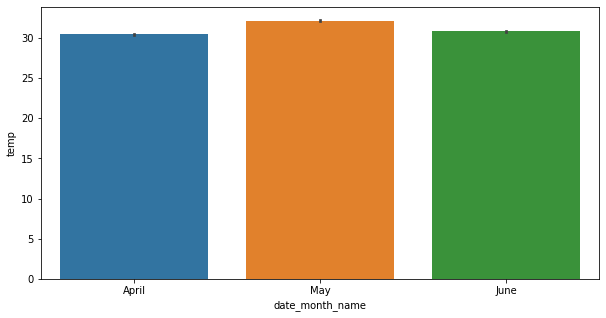

In [17]:
plt.figure(figsize=(10,5))
sns.barplot(x = 'date_month_name',
            y = 'temp',
            data = df2)
 
# Show the plot
plt.show()

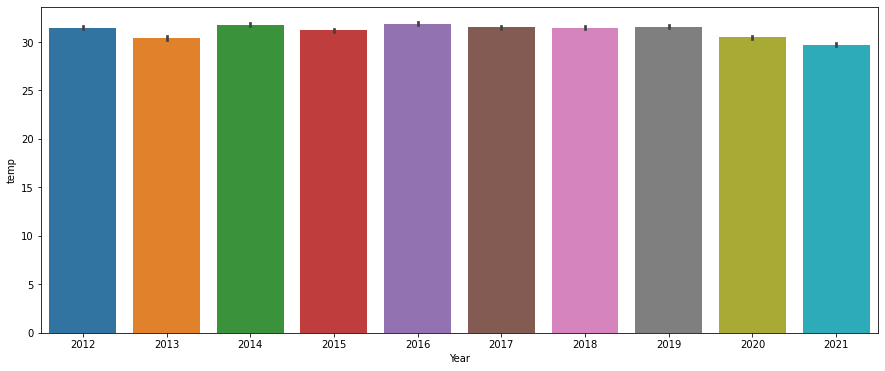

In [18]:
plt.figure(figsize=(15,6))
sns.barplot(x = 'Year',
            y = 'temp',
            data = df2)
 
# Show the plot
plt.show()

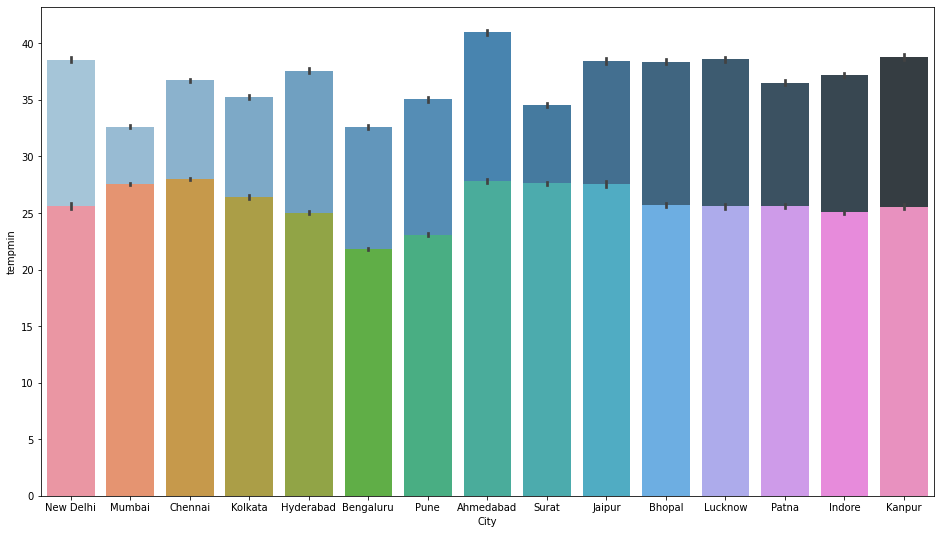

In [19]:
plt.figure(figsize=(16,9))
sns.barplot(x = 'City',
            y = 'tempmax',linewidth=10,
            data = df2,palette="Blues_d") and sns.barplot(x = 'City',
            y = 'tempmin',data = df2)   
# Show the plot
plt.show()

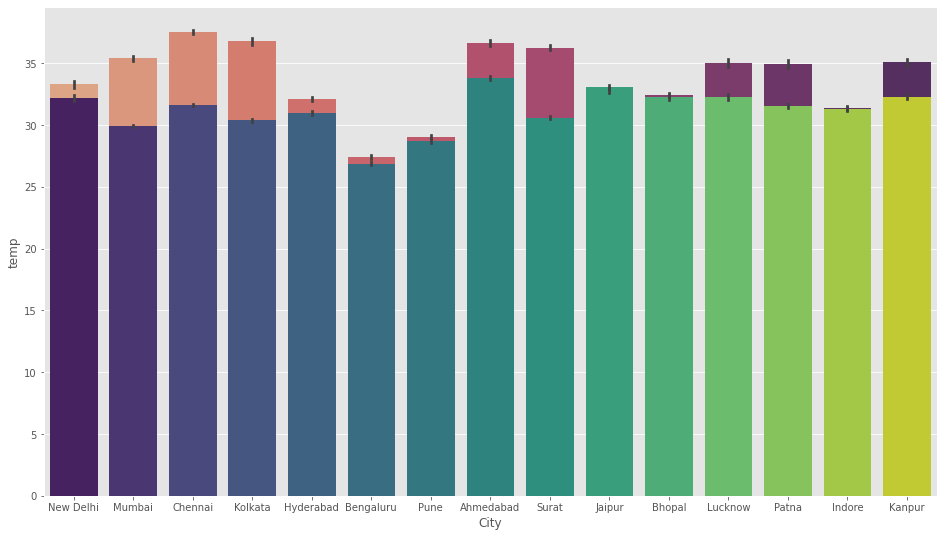

In [53]:
plt.figure(figsize=(16,9))
style.use("ggplot")
sns.barplot(x = 'City',
            y = 'feelslike',linewidth=10,
            data = df2,palette='flare') and sns.barplot(x = 'City',
            y = 'temp',data = df2, palette= "viridis")   
# Show the plot
plt.show()